In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
img_size=32
dataset_path="C:/Users/Admin/Desktop/AI-ML/fruits_prediction/Fruits"

In [3]:
x=[]
y=[]
categories=["Apple","Mango"]

In [4]:
for label,category in enumerate(categories):
    folder_path=os.path.join(dataset_path,category)
    print(folder_path)
    if not os.path.exists(folder_path):
        print("Path Not Found")
    for img_name in os.listdir(folder_path):
        if img_name.startswith('.'):
            continue
        img_path=os.path.join(folder_path,img_name)
        img=cv2.imread(img_path)
        # img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        if img is None:
            print("Could Not Read Image",img_path)
            continue
        img = cv2.resize(img, (img_size, img_size))
        img_flat=img.flatten()
        x.append(img_flat)
        y.append(label)
# print(y)

C:/Users/Admin/Desktop/AI-ML/fruits_prediction/Fruits\Apple
C:/Users/Admin/Desktop/AI-ML/fruits_prediction/Fruits\Mango


In [5]:
x=np.array(x)
y=np.array(y)
x=x/255.0
scores=[]
labels=[]

In [6]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

In [7]:
Lr=LogisticRegression()

In [8]:
Lr.fit(x_train,y_train)

LogisticRegression()

In [9]:
Lr.score(x_train,y_train)

1.0

In [10]:
Lr.score(x_test,y_test)

1.0

In [11]:
y_pred=Lr.predict(x_test)

In [12]:
y_pred=Lr.predict(x_test)
print("Accuracy Of Logistic Regression Without Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of Logistic Regression Without Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of Logistic Regression Without Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of Logistic Regression Without Hyper Paramter Tuning::> 100.0
Classfication Report Of Logistic Regression Without Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of Logistic Regression Without Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [13]:
param_grid={
    'C':[0.001,0.01,1],
    'penalty':['l2'],
    'solver':['liblinear','lbfgs'],
    'max_iter':[100,200,500],
    # 'class_weight':[None,'balanced']
}

In [14]:
grid_Lr=GridSearchCV(
    estimator=Lr,
    param_grid=param_grid,
    cv=5,
    verbose=1,
    scoring='f1',
    n_jobs=-1
)

In [15]:
grid_Lr.fit(x_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 1], 'max_iter': [100, 200, 500],
                         'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']},
             scoring='f1', verbose=1)

In [16]:
grid_Lr.best_score_

1.0

In [17]:
grid_Lr.best_params_

{'C': 0.001, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

In [18]:
model_Lr=grid_Lr.best_estimator_

In [19]:
model_Lr.fit(x_train,y_train)

LogisticRegression(C=0.001, solver='liblinear')

In [20]:
model_Lr.score(x_train,y_train)*100

100.0

In [21]:
model_Lr.score(x_test,y_test)*100

100.0

In [22]:
y_pred=model_Lr.predict(x_test)
print("Accuracy Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::> 100.0
Classfication Report Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of Logistic Regression With Grid SerchCV Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [23]:
new_image_path=r"C:\Users\Admin\Downloads\test\Apple_test\Apple Braeburn_142.jpg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img=img/255
img=img.flatten()
process_image=img.reshape(1,-1)

prediction=Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Apple


it gives 100% accuracy with and without hyperparamter tuning so now we check cv score

In [24]:
new_image_path=r"C:\Users\Admin\Downloads\test\Mango_test\Mango_14.jpg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [25]:
cross_Lr=cross_val_score(model_Lr,x_train,y_train,cv=5,scoring='accuracy')
print("CV_Scores::>",cross_Lr)
print("Best CV Score::>",cross_Lr.mean())

CV_Scores::> [1. 1. 1. 1. 1.]
Best CV Score::> 1.0


In [26]:
random_Lr=RandomizedSearchCV(
    Lr,
    param_distributions=param_grid,
    verbose=1,
    cv=5,
    n_iter=10,
    n_jobs=-1
)

In [27]:
random_Lr.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 1],
                                        'max_iter': [100, 200, 500],
                                        'penalty': ['l2'],
                                        'solver': ['liblinear', 'lbfgs']},
                   verbose=1)

In [28]:
random_Lr.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 500, 'C': 0.01}

In [29]:
random_Lr.best_score_

1.0

In [30]:
r_model_Lr=random_Lr.best_estimator_

In [31]:
r_model_Lr.score(x_train,y_train)

1.0

In [32]:
r_model_Lr.score(x_test,y_test)

1.0

In [33]:
y_pred=r_model_Lr.predict(x_test)
score=accuracy_score(y_test,y_pred)*100
scores.append(score)
labels.append('LR')
print("Accuracy Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::> 100.0
Classfication Report Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of Logistic Regression With Randomized SearchCV Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In Logistic regression it gives 100% accuracy so it's working good now we can try on new data for apples and mangoes

In [34]:
new_image_path=r"C:\Users\Admin\Downloads\test\Apple_test\Apple Braeburn_13.jpg"

img=cv2.imread(new_image_path)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Apple


In [35]:
knn=KNeighborsClassifier()

In [36]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [37]:
knn.score(x_train,y_train)

1.0

In [38]:
knn.score(x_test,y_test)

1.0

In [39]:
y_pred=knn.predict(x_test)
print("Accuracy Of knn Without Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of knn Without Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of knn Without Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of knn Without Hyper Paramter Tuning::> 100.0
Classfication Report Of knn Without Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of knn Without Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


Here without hyperparamter tuning it gives 100% accureacy which shows model learn perfect but when we try on new unseen data then we found model is learn pattern correctly or not

In [40]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],           
    'weights': ['uniform', 'distance'],    
    'metric': ['euclidean', 'manhattan']   
}

In [41]:
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [42]:
grid_knn.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [43]:
grid_knn.best_score_

1.0

In [44]:
grid_knn.best_params_

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

In [45]:
model_knn=grid_knn.best_estimator_

In [46]:
model_knn.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [47]:
model_knn.score(x_train,y_train)

1.0

In [48]:
model_knn.score(x_test,y_test)

1.0

In [49]:
y_pred=model_knn.predict(x_test)
print("Accuracy Of knn With Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of knn With Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of knn Without Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of knn With Hyper Paramter Tuning::> 100.0
Classfication Report Of knn With Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of knn Without Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [50]:
cross_knn=cross_val_score(knn,x_train,y_train,cv=5,scoring='f1')
print("CV_Scores::>",cross_knn)
print("Best CV Score::>",cross_knn.mean())

CV_Scores::> [1. 1. 1. 1. 1.]
Best CV Score::> 1.0


In [51]:
random_knn=RandomizedSearchCV(
    knn,
    param_distributions=param_grid,
    verbose=1,
    cv=5,
    n_iter=10,
    n_jobs=-1
)

In [52]:
random_knn.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
                   param_distributions={'metric': ['euclidean', 'manhattan'],
                                        'n_neighbors': [3, 5, 7, 9],
                                        'weights': ['uniform', 'distance']},
                   verbose=1)

In [53]:
random_knn.best_score_

1.0

In [54]:
random_knn.best_params_

{'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}

In [55]:
r_knn=random_knn.best_estimator_

In [56]:
r_knn.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [57]:
r_knn.score(x_train,y_train)

1.0

In [58]:
r_knn.score(x_test,y_test)

1.0

In [59]:
y_pred=r_knn.predict(x_test)
score=accuracy_score(y_test,y_pred)
scores.append(score)
labels.append('KNN')
print("Accuracy Of knn With Randomized SearchCV Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of knn With Randomized SearchCV Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of knn With Randomized SearchCV Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of knn With Randomized SearchCV Hyper Paramter Tuning::> 100.0
Classfication Report Of knn With Randomized SearchCV Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of knn With Randomized SearchCV Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [60]:
new_image_path=r"C:\Users\Admin\Downloads\test\Apple_test\Apple Braeburn_142.jpg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img=img/255
img=img.flatten()
process_image=img.reshape(1,-1)

prediction=r_knn.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Apple


In [61]:
new_image_path=r"C:\Users\Admin\Downloads\test\Mango_test\Mango_14.jpg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_knn.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [62]:
decision=DecisionTreeClassifier()

In [63]:
decision.fit(x_train,y_train)

DecisionTreeClassifier()

In [64]:
decision.score(x_train,y_train)

1.0

In [65]:
decision.score(x_test,y_test)

1.0

In [66]:
y_pred=decision.predict(x_test)
print("Accuracy Of decision tree classfier Without Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of decision tree classfier Without Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of decision tree classfier Without Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of decision tree classfier Without Hyper Paramter Tuning::> 100.0
Classfication Report Of decision tree classfier Without Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of decision tree classfier Without Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


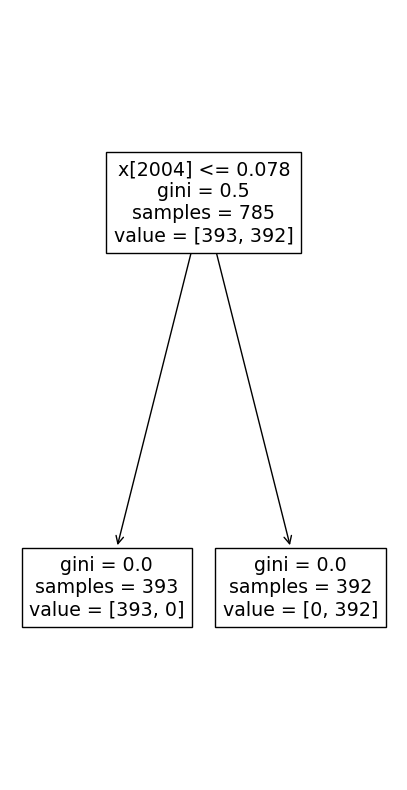

In [67]:
plt.figure(figsize=(5,10))
plot_tree(decision)
plt.savefig('fruits_decision.jpg')
plt.show()

In [68]:
param_grid={
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5,None],
}

In [69]:
grid_decision=GridSearchCV(
    estimator=decision,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [70]:
grid_decision.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, None]},
             scoring='accuracy', verbose=1)

In [71]:
grid_decision.best_score_

1.0

In [72]:
grid_decision.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [73]:
model_decision=grid_decision.best_estimator_

In [74]:
model_decision.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [75]:
model_decision.score(x_train,y_train)

1.0

In [76]:
model_decision.score(x_test,y_test)

1.0

In [77]:
y_pred=model_decision.predict(x_test)
print("Accuracy Of decision tree classfier With Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of decision tree classfier With Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of decision tree classfier With Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of decision tree classfier With Hyper Paramter Tuning::> 100.0
Classfication Report Of decision tree classfier With Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of decision tree classfier With Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


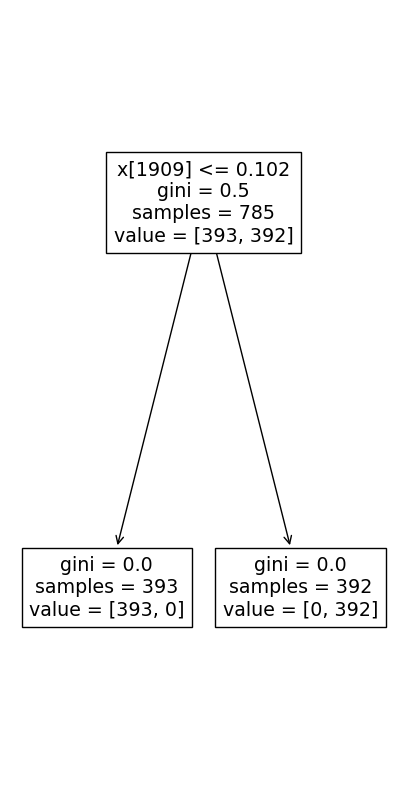

In [78]:
plt.figure(figsize=(5,10))
plot_tree(model_decision)
plt.savefig('fruits_grid_decision.jpg')
plt.show()

In [79]:
cross_knn=cross_val_score(model_decision,x_train,y_train,cv=5,scoring='accuracy')
print("CV_Scores::>",cross_knn)
print("Best CV Score::>",cross_knn.mean())

CV_Scores::> [1. 1. 1. 1. 1.]
Best CV Score::> 1.0


In [80]:
random_decision=RandomizedSearchCV(
    decision,
    param_distributions=param_grid,
    verbose=1,
    cv=5,
    n_iter=10,
    n_jobs=-1
)

In [81]:
random_decision.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3, 4, 5, None]},
                   verbose=1)

In [82]:
random_decision.best_score_

1.0

In [83]:
random_decision.best_params_

{'max_depth': 3, 'criterion': 'gini'}

In [84]:
r_decision=random_decision.best_estimator_

In [85]:
r_decision.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [86]:
r_decision.score(x_train,y_train)

1.0

In [87]:
r_decision.score(x_test,y_test)

1.0

In [88]:
y_pred=r_decision.predict(x_test)
score=accuracy_score(y_test,y_pred)
scores.append(score)
labels.append('Decision')
print("Accuracy Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::> 100.0
Classfication Report Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of decision tree classfier With Randomized SearchCV Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


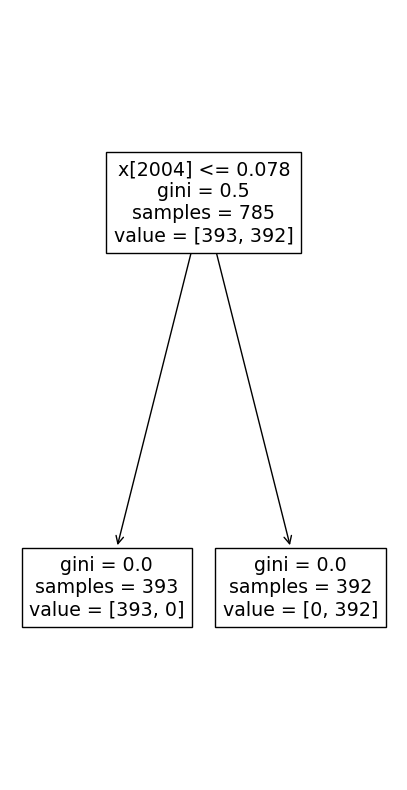

In [89]:
plt.figure(figsize=(5,10))
plot_tree(r_decision)
plt.savefig('fruits_random_decision.jpg')
plt.show()

In [90]:
new_image_path=r"C:\Users\Admin\Downloads\test\Apple_test\Apple Braeburn_142.jpg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img=img/255
img=img.flatten()
process_image=img.reshape(1,-1)

prediction=r_decision.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Apple


In [91]:
new_image_path=r"C:\Users\Admin\Downloads\test\Mango_test\Mango_14.jpg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_decision.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [92]:
random=RandomForestClassifier()

In [93]:
random.fit(x_train,y_train)

RandomForestClassifier()

In [94]:
random.score(x_train,y_train)

1.0

In [95]:
random.score(x_test,y_test)

1.0

In [96]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20, 40],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt'],
    'class_weight': [None, 'balanced'],
    'bootstrap': [True]
}

In [97]:
grid_random=GridSearchCV(
    estimator=random,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [98]:
grid_random.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True],
                         'class_weight': [None, 'balanced'],
                         'max_depth': [None, 20, 40], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 3],
                         'n_estimators': [200, 400]},
             scoring='accuracy', verbose=1)

In [99]:
grid_random.best_score_

1.0

In [100]:
grid_random.best_params_

{'bootstrap': True,
 'class_weight': None,
 'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'n_estimators': 200}

In [101]:
model_random=grid_random.best_estimator_

In [102]:
model_random.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [103]:
model_random.score(x_train,y_train)

1.0

In [104]:
model_random.score(x_test,y_test)

1.0

In [105]:
y_pred=model_random.predict(x_test)
print("Accuracy Of Random Forest classfier With Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of Random Forest classfier With Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of Random Forest classfier With Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of Random Forest classfier With Hyper Paramter Tuning::> 100.0
Classfication Report Of Random Forest classfier With Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of Random Forest classfier With Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [106]:
cross_knn=cross_val_score(model_random,x_train,y_train,cv=5,scoring='accuracy')
print("CV_Scores::>",cross_knn)
print("Best CV Score::>",cross_knn.mean())

CV_Scores::> [1. 1. 1. 1. 1.]
Best CV Score::> 1.0


In [107]:
random_rf=RandomizedSearchCV(
    random,
    param_distributions=param_grid,
    verbose=1,
    cv=5,
    n_iter=10,
    n_jobs=-1
)

In [108]:
random_rf.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 20, 40],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 3],
                                        'n_estimators': [200, 400]},
                   verbose=1)

In [109]:
random_rf.best_score_

1.0

In [110]:
random_rf.best_params_

{'n_estimators': 400,
 'min_samples_leaf': 3,
 'max_features': 'sqrt',
 'max_depth': 40,
 'class_weight': 'balanced',
 'bootstrap': True}

In [111]:
r_random=random_rf.best_estimator_

In [112]:
r_random.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=40,
                       min_samples_leaf=3, n_estimators=400)

In [113]:
r_random.score(x_train,y_train)

1.0

In [114]:
r_random.score(x_test,y_test)

1.0

In [115]:
y_pred=r_random.predict(x_test)
score=accuracy_score(y_test,y_pred)*100
scores.append(score)
labels.append('Random Forest')
print("Accuracy Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::>",accuracy_score(y_test,y_pred)*100)
print("Classfication Report Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::>\n",classification_report(y_test,y_pred))
print("Confusion Matrix Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::>\n",confusion_matrix(y_test,y_pred))

Accuracy Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::> 100.0
Classfication Report Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::>
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00        98

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197

Confusion Matrix Of Random Forest classfier With Randomized SearchCV Hyper Paramter Tuning::>
 [[99  0]
 [ 0 98]]


In [116]:
new_image_path=r"C:\Users\Admin\Downloads\test\Apple_test\Apple Braeburn_142.jpg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img=img/255
img=img.flatten()
process_image=img.reshape(1,-1)

prediction=r_random.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Apple


In [117]:
new_image_path=r"C:\Users\Admin\Downloads\test\Mango_test\Mango_14.jpg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_random.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


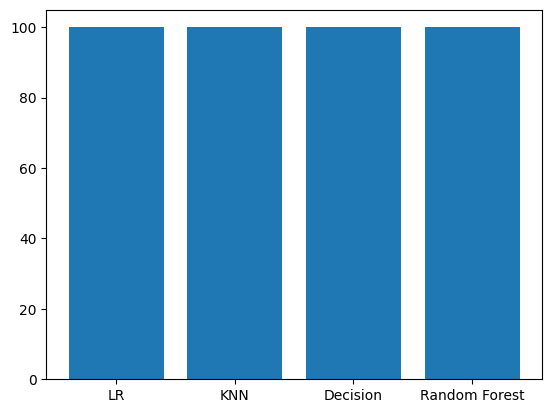

In [118]:
plt.bar(labels,score)
plt.show()

In [119]:
new_image_path=r"C:\Users\Admin\Desktop\ML\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM.jpeg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=model_Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [120]:
new_image_path=r"C:\Users\Admin\Desktop\ML\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM.jpeg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_knn.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [121]:
new_image_path=r"C:\Users\Admin\Desktop\ML\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM.jpeg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_decision.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [122]:
new_image_path=r"C:\Users\Admin\Desktop\ML\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM.jpeg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_random.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [123]:
new_image_path=r"C:\Users\Admin\Desktop\ML\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM (2).jpeg"

img=cv2.imread(new_image_path)
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_model_Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [124]:
new_image_path=r"C:\Users\Admin\Downloads\test\Mango_test\Mango_14.jpg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_knn.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [125]:
new_image_path=r"C:\Users\Admin\Desktop\AI-ML\fruits_prediction\Fruits\WhatsApp Image 2026-02-11 at 7.07.30 PM (2).jpeg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_decision.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [126]:
new_image_path=r"C:\Users\Admin\Desktop\AI-ML\fruits_prediction\Fruits\WhatsApp Image 2026-02-11 at 7.07.29 PM.jpeg"

img=cv2.imread(new_image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(img_size,img_size))
img=img/255
img=img.flatten()
process_image=img.reshape(1,-1)

prediction=Lr.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [127]:
new_image_path=r"C:\Users\Admin\Desktop\AI-ML\fruits_prediction\Fruits\WhatsApp Image 2026-02-11 at 7.07.29 PM.jpeg"

img=cv2.imread(new_image_path)
img=cv2.resize(img,(img_size,img_size))
img_flat=img.flatten()/255.0
process_image=img_flat.reshape(1,-1)

prediction=r_decision.predict(process_image)
if(prediction[0]==0):
    print("Apple")
else:
    print("Mango")

Mango


In [128]:
import joblib

In [129]:
joblib.dump(decision,'model.pkl')

['model.pkl']